⚠️ 'outputs/cleaned_data/cleaned_deliveries.csv' was empty or missing.
👉 Safely falling back to raw data stream: C:\Users\Admin\IPL-DataAnalysis\IPL-Data-Analysis\data\deliveries.csv
Success! Loaded 1090 matches and 260920 delivery records cleanly.
Processing Venue Archetypes...


C:\Users\Admin\AppData\Local\Temp\ipykernel_11748\1317726302.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


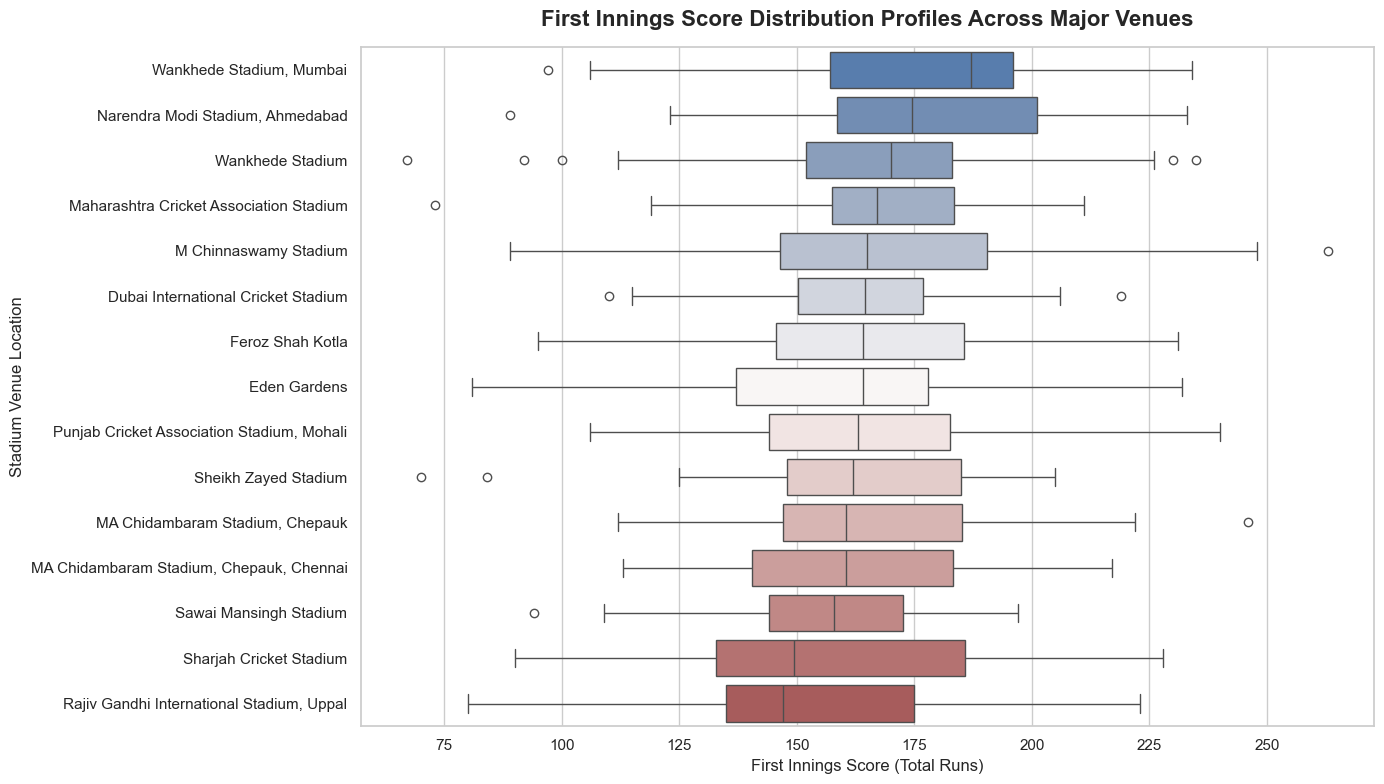

Processing Head-to-Head Dominance Heatmap...


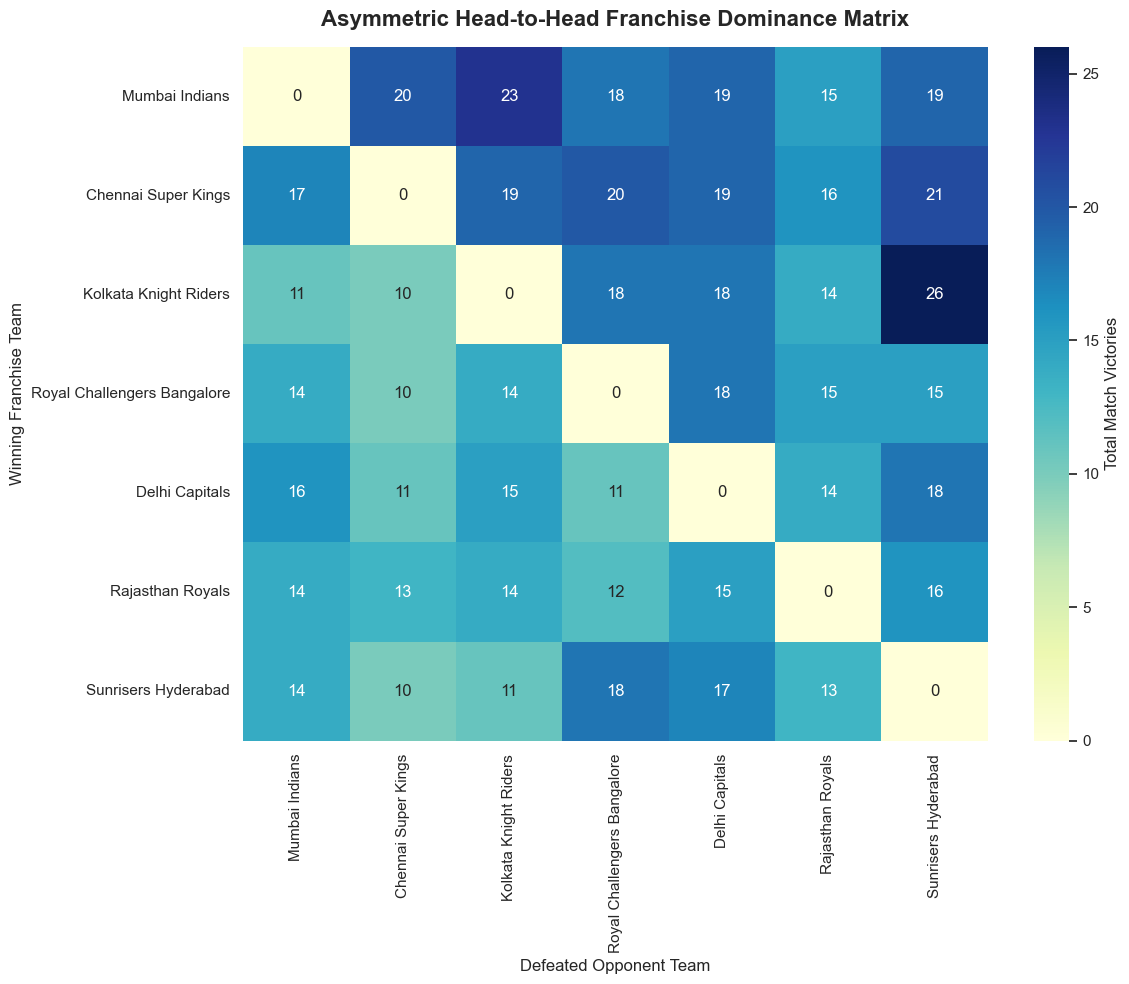

Notebook 02 analysis block successfully executed!


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup professional visualization formatting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# 1. Absolute Path Initializer
# 1. Absolute Path Initializer
BASE_DIR = r"C:\Users\Admin\IPL-DataAnalysis\IPL-Data-Analysis"
MATCHES_PATH = os.path.join(BASE_DIR, "outputs", "cleaned_data", "cleaned_matches.csv")
DELIVERIES_PATH = os.path.join(BASE_DIR, "outputs", "cleaned_data", "cleaned_deliveries.csv")

matches = pd.read_csv(MATCHES_PATH)

# FIXED FALLBACK ENGINE: Checks if file exists AND has actual data in it
if os.path.exists(DELIVERIES_PATH) and os.path.getsize(DELIVERIES_PATH) > 0:
    deliveries = pd.read_csv(DELIVERIES_PATH)
else:
    # If the cleaned file is empty or missing, safely fall back to your working raw dataset
    raw_deliveries_path = os.path.join(BASE_DIR, "data", "deliveries.csv")
    print(f"⚠️ 'outputs/cleaned_data/cleaned_deliveries.csv' was empty or missing.")
    print(f"👉 Safely falling back to raw data stream: {raw_deliveries_path}")
    deliveries = pd.read_csv(raw_deliveries_path)

print(f"Success! Loaded {len(matches)} matches and {len(deliveries)} delivery records cleanly.")

# 2. Team Name Standardization Dictionary (Removes historical branding clutter)
team_mappings = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_mappings)

# --- ANALYSIS 1: Venue-Wise Scoring Archetypes ---
# Objective: Classify grounds into batting paradises vs low-scoring tracks
print("Processing Venue Archetypes...")
# Calculate total runs per match per inning
match_scores = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
first_innings = match_scores[match_scores['inning'] == 1]

# Map venue names back from matches
venue_mapped_scores = pd.merge(first_innings, matches[['id', 'venue']], left_on='match_id', right_on='id')

# Filter for top 15 stadiums by match count to minimize baseline noise
top_venues = venue_mapped_scores['venue'].value_counts().nlargest(15).index
filtered_venues = venue_mapped_scores[venue_mapped_scores['venue'].isin(top_venues)]

# Plotting the Distribution Profiles
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=filtered_venues, 
    x='total_runs', 
    y='venue', 
    palette='vlag', 
    order=filtered_venues.groupby('venue')['total_runs'].median().sort_values(ascending=False).index
)
plt.title('First Innings Score Distribution Profiles Across Major Venues', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('First Innings Score (Total Runs)', fontsize=12)
plt.ylabel('Stadium Venue Location', fontsize=12)
plt.tight_layout()
os.makedirs(os.path.join(BASE_DIR, "outputs", "insights"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "outputs", "insights", "venue_scoring_dna.png"))
plt.show()

# --- ANALYSIS 2: Team Head-to-Head Dominance Matrix ---
# Objective: Map structural match advantages across competitive rivalries
print("Processing Head-to-Head Dominance Heatmap...")
# Filter out matches with no clear winner result (abandoned games)
valid_matches = matches[matches['winner'].notna()]

# Create a clean pairwise matrix layout counting victories
h2h_counts = pd.crosstab(valid_matches['winner'], valid_matches['team1'] == valid_matches['winner']) 
# Alternatively, a complete crosstab mapping row teams vs column teams:
h2h_matrix = pd.crosstab(valid_matches['winner'], [valid_matches['team1'], valid_matches['team2']])
# Standard cross mapping for top active franchises
top_franchises = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders', 
                  'Royal Challengers Bangalore', 'Delhi Capitals', 'Rajasthan Royals', 'Sunrisers Hyderabad']

pure_matrix = pd.DataFrame(0, index=top_franchises, columns=top_franchises)
for _, row in valid_matches.iterrows():
    w, t1, t2 = row['winner'], row['team1'], row['team2']
    opponent = t2 if w == t1 else t1
    if w in top_franchises and opponent in top_franchises:
        pure_matrix.loc[w, opponent] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(pure_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Total Match Victories'})
plt.title('Asymmetric Head-to-Head Franchise Dominance Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Defeated Opponent Team', fontsize=12)
plt.ylabel('Winning Franchise Team', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "outputs", "insights", "rivalry_heatmap.png"))
plt.show()
print("Notebook 02 analysis block successfully executed!")